## 1. Environment Setup

In [1]:
import os, sys, pickle, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebooks have no __file__, and the working directory differs between Jupyter
# (the notebook's folder) and VSCode (the workspace root). So instead of relying
# on either, locate the project root by walking up until we find its marker dirs.

def _find_project_root(start):
    p = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(p, 'edm_repo')) and \
           os.path.isdir(os.path.join(p, 'alps')):
            return p
        parent = os.path.dirname(p)
        if parent == p:            # reached filesystem root
            return None
        p = parent

# Search from the cwd, then from a few likely starting points.

PROJECT_ROOT = (
    _find_project_root(os.getcwd())
    or _find_project_root(os.path.join(os.getcwd(), 'alps'))
    or _find_project_root(os.path.join(os.getcwd(), '..'))
)
if PROJECT_ROOT is None:
    # Fallback: set manually if auto-detection fails.
    # PROJECT_ROOT = '/home2/wzr8sn/Work/cascade_diffusion_mri'
    raise RuntimeError(
        'Could not locate project root (a dir containing both edm_repo/ and '
        'alps/). Set PROJECT_ROOT manually in this cell.'
    )

for _p in [
    os.path.join(PROJECT_ROOT, 'edm_repo'),
    os.path.join(PROJECT_ROOT, 'scripts'),
    PROJECT_ROOT,
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

print(f'Project root : {PROJECT_ROOT}')

Project root : /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion


In [2]:
# Needed so pickle can reconstruct the SR model class
from edm_sr_model import EDMSRPrecond          # noqa
from training.networks import EDMPrecond        # noqa

from alps.operators import (MRIOperator, avg_pool_complex,
                            make_cartesian_mask, crop_kspace_center,make_radial_mask)
from alps.denoiser  import BaseDenoiser, SRDenoiser
from alps.sampling  import ALPSOptions, ALPS, cascaded_ALPS, giveTsteps

print('Imports OK')

Imports OK


## 2. Configuration

In [89]:
# ═══════════════════════════════════════════════════════════════════════════════
#  EDIT THESE PATHS / SETTINGS
# ═══════════════════════════════════════════════════════════════════════════════

GPU_ID = 2
device = torch.device(f'cuda:{GPU_ID}' if torch.cuda.is_available() else 'cpu')

# Checkpoint paths — the trained MRI EDM checkpoints live here:
CKPT_ROOT = '/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints'
BASE_CKPT = os.path.join(CKPT_ROOT, 'edm_mri_base_96/network-snapshot-027597.pkl')
SR_CKPT   = os.path.join(CKPT_ROOT, 'edm_mri_sr_384/network-snapshot-006203.pkl')
# SR_CKPT   = "/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_sr_384/network-snapshot-003692.pkl"

DATA_PT   = '/CBIG-Standard-ECE/aniket/FastMRI_brain_data_all/AXT2/file_brain_AXT2_200_6002235.pkl'
SLICE_IDX = 2      # which slice to reconstruct

# Forward model
ACCELERATION  = 3
ACS_FRACTION  = 0.07

ETA           = 0.08
SEED          = 42

SIGMA_MAX   = 1.0
SIGMA_MIN   = 0.001  
RHO         = 7.0
STEPS_BASE  = 10   
STEPS_SR    = 15   

K           = 5   
STEP_SIZE = 1.0/math.sqrt(K)

CG_ITERS    = 10  


print(f'Device        : {device}')
print(f'Acceleration  : {ACCELERATION}\xd7')
print(f'ETA           : {ETA}  (data fidelity strength)')
print(f'ALPS steps    : Stage1={STEPS_BASE}, Stage2={STEPS_SR}, K={K}')
print(f'sigma range   : {SIGMA_MAX} \u2192 {SIGMA_MIN}  (rho={RHO})')
print()
print('Fine-line recovery config:')
print(f'  - Low eta ({ETA}) amplifies data term vs prior')
print(f'  - sigma_min={SIGMA_MIN} stops before over-smoothing regime')
print(f'  - K=1 avoids repeated denoiser averaging per noise level')



Device        : cuda:2
Acceleration  : 3×
ETA           : 0.08  (data fidelity strength)
ALPS steps    : Stage1=10, Stage2=15, K=5
sigma range   : 1.0 → 0.001  (rho=7.0)

Fine-line recovery config:
  - Low eta (0.08) amplifies data term vs prior
  - sigma_min=0.001 stops before over-smoothing regime
  - K=1 avoids repeated denoiser averaging per noise level


## 3. Load MRI Slice

In [90]:
def _enable_numpy2_pickle_compat():
    """
    Allow unpickling NumPy>=2.0 pickles under an older NumPy (<2.0).

    NumPy 2.0 renamed the private package ``numpy.core`` → ``numpy._core``, so
    arrays pickled with NumPy 2.x reference ``numpy._core.*`` which an older
    NumPy can't import. We alias the submodules back to ``numpy.core.*``.
    No-op when ``numpy._core`` already exists.
    """
    import importlib, pkgutil
    try:
        import numpy._core  # noqa: F401  (NumPy>=2.0, or 1.26 shim)
        import numpy._core.multiarray  # noqa: F401  (ensure it's importable)
        return
    except ModuleNotFoundError:
        pass
    import numpy.core as _np_core
    sys.modules.setdefault('numpy._core', _np_core)
    for _, modname, _ in pkgutil.iter_modules(_np_core.__path__):
        try:
            sys.modules.setdefault('numpy._core.' + modname,
                                   importlib.import_module('numpy.core.' + modname))
        except Exception:
            pass

def _ifft2c_np(x):
    """Centred orthonormal 2D inverse FFT over the last two axes (numpy complex)."""
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(x, axes=(-2, -1)), norm='ortho'),
        axes=(-2, -1),
    )

def load_multicoil(path, slice_idx):
    """
    Load one slice of raw fastMRI multi-coil data.

    Returns
    -------
    kspace_mc : (1, C, 384, 384) complex   multi-coil k-space (normalised)
    csm       : (1, C, 384, 384) complex   coil-sensitivity maps
    x_gt      : (1, 2, 384, 384) float32    SENSE coil-combined image (mag ≤ 1)
    """
    _enable_numpy2_pickle_compat()           # raw .pkl was written with NumPy 2.x
    with open(path, 'rb') as f:
        o = pickle.load(f)
    ksp = torch.from_numpy(o['cropped_kspace'][slice_idx]).to(torch.complex64)[None]
    csm = torch.from_numpy(o['coil_sensitivity_maps'][slice_idx]).to(torch.complex64)[None]
    # SENSE coil-combine → complex image, normalise so max magnitude = 1
    comb  = (csm.conj() * torch.from_numpy(_ifft2c_np(o['cropped_kspace'][slice_idx])[None]).to(torch.complex64)).sum(1)
    scale = comb.abs().max()
    ksp   = ksp / scale
    comb  = comb / scale
    x_gt  = torch.stack([comb.real, comb.imag], dim=1)   # (1, 2, 384, 384)
    return ksp, csm, x_gt

kspace_mc, csm, x_gt = load_multicoil(DATA_PT, SLICE_IDX)
kspace_mc = kspace_mc.to(device); csm = csm.to(device); x_gt = x_gt.to(device)

print(f'File   : {DATA_PT}')
print(f'k-space: {tuple(kspace_mc.shape)}  ({kspace_mc.shape[1]} coils)  dtype={kspace_mc.dtype}')
print(f'csm    : {tuple(csm.shape)}')
print(f'x_gt   : {tuple(x_gt.shape)}  (SENSE combined)  mag_max={torch.sqrt(x_gt[:,0]**2+x_gt[:,1]**2).max():.3f}')

File   : /CBIG-Standard-ECE/aniket/FastMRI_brain_data_all/AXT2/file_brain_AXT2_200_6002235.pkl
k-space: (1, 20, 384, 384)  (20 coils)  dtype=torch.complex64
csm    : (1, 20, 384, 384)
x_gt   : (1, 2, 384, 384)  (SENSE combined)  mag_max=1.000


## 4. Simulate Forward Problem

### 4.1 Compute fully-sampled k-space

In [91]:
def image_to_kspace(x: torch.Tensor) -> torch.Tensor:
    """(B,2,H,W) single-channel image → (B,2,H,W) k-space (display helper)."""
    xc = torch.complex(x[:, 0], x[:, 1])
    kc = torch.fft.fft2(xc, norm='ortho')
    return torch.stack([kc.real, kc.imag], dim=1)

def kspace_to_image(k: torch.Tensor) -> torch.Tensor:
    """(B,2,H,W) k-space → (B,2,H,W) image (display helper)."""
    kc = torch.complex(k[:, 0], k[:, 1])
    xc = torch.fft.ifft2(kc, norm='ortho')
    return torch.stack([xc.real, xc.imag], dim=1)

# The acquisition is the multi-coil k-space loaded above (the real measurement).
kspace_full = kspace_mc   # (1, C, 384, 384) complex
print(f'Multi-coil k-space: {tuple(kspace_full.shape)}  ({kspace_full.shape[1]} coils)')

Multi-coil k-space: (1, 20, 384, 384)  (20 coils)


### 4.2 Build operators and extract measurements

In [92]:
# Average-pool the coil maps and build masks *outside* the operator.
# Stage 1 works at 96x96; fft_scale = 384/96 = 4 so the pooled-image forward
# model reproduces the measured 384x384 k-space centre.
FULL = kspace_full.shape[-1]        # image resolution (e.g. 320 or 384)
LOW  = FULL // 4                     # low-res stage resolution
POOL = FULL // LOW                   # pooling factor = 4

csm_96 = avg_pool_complex(csm, POOL)   # (1, C, LOW, LOW) pooled coil maps

# Load the pre-computed 4x acceleration Cartesian mask
# acc4_c 2.npy  shape: (320, 320), dtype: complex64, 1D Cartesian (~4x accel)
import os as _os
_mask_path = _os.path.join(
    _os.path.dirname(_os.path.abspath('__file__')), 'acc4_c 2.npy')
mask_np   = np.load(_mask_path).real.astype(np.float32)          # (320, 320)
mask_full = torch.tensor(mask_np).unsqueeze(0).unsqueeze(0)      # (1,1,320,320)

# If data resolution differs from mask resolution, zero-pad to match.
if mask_full.shape[-1] != FULL:
    pad = (FULL - mask_full.shape[-1]) // 2
    mask_full = torch.nn.functional.pad(mask_full, (pad, pad, pad, pad))
    print(f'Mask padded 320x320 -> {FULL}x{FULL}')

mask_384 = mask_full.to(device)             # Stage 2 mask  (1,1,FULL,FULL)
mask_96  = crop_kspace_center(mask_384, LOW) # Stage 1 mask  (1,1,LOW,LOW)

print(f'mask_384 shape: {tuple(mask_384.shape)},  '
      f'acquired lines: {int(mask_384[0,0,:,0].sum())}/{FULL}')
print(f'mask_96  shape: {tuple(mask_96.shape)},  '
      f'acquired lines: {int(mask_96[0,0,:,0].sum())}/{LOW}')

# Stage 1 SENSE operator -- LOW x LOW (pooled image + pooled coil maps)
A1 = MRIOperator(
    csm       = csm_96,
    mask      = mask_96,
    eta       = ETA,
    cg_iters  = CG_ITERS,
    fft_scale = FULL / LOW,    # = 4
    device    = device,
)

# Stage 2 SENSE operator -- FULL x FULL (full multi-coil model)
A2 = MRIOperator(
    csm       = csm,
    mask      = mask_384,
    eta       = ETA,
    cg_iters  = CG_ITERS,
    fft_scale = 1.0,
    device    = device,
)

# Multi-coil measurements (mask applied inside get_measurements; y1 is the
# masked centre crop of the real k-space). The acquired k-space is already
# noisy, so we do NOT add synthetic measurement noise.
y1 = A1.get_measurements(kspace_full)   # (1, C, LOW,  LOW)  complex
y2 = A2.get_measurements(kspace_full)   # (1, C, FULL, FULL) complex

print(f'y1 (Stage 1 multi-coil measurements): {tuple(y1.shape)}')
print(f'y2 (Stage 2 multi-coil measurements): {tuple(y2.shape)}')


Mask padded 320x320 -> 384x384
mask_384 shape: (1, 1, 384, 384),  acquired lines: 0/384
mask_96  shape: (1, 1, 96, 96),  acquired lines: 0/96
[MRIOperator] 96×96 SENSE, 20 coils, fft_scale=4, 0/96 lines acquired (actual 96.0×)
[MRIOperator] 384×384 SENSE, 20 coils, fft_scale=1, 0/384 lines acquired (actual 384.0×)
y1 (Stage 1 multi-coil measurements): (1, 20, 96, 96)
y2 (Stage 2 multi-coil measurements): (1, 20, 384, 384)


### 4.3 Visualise masks and zero-filled reconstructions

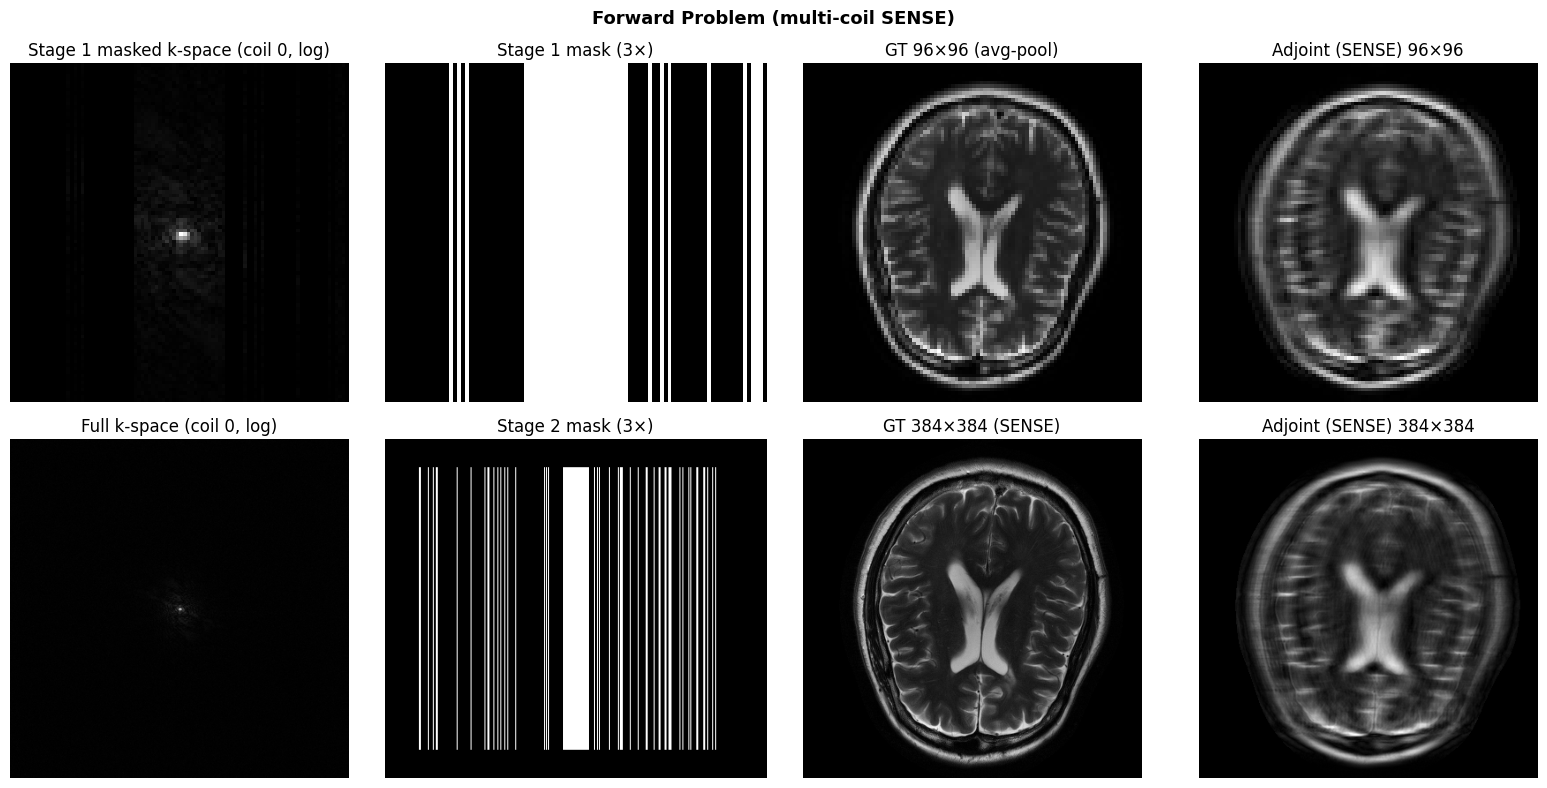

In [93]:
def magnitude(x: torch.Tensor) -> np.ndarray:
    """(B,2,H,W) → (H,W) magnitude of first sample, normalised [0,1]."""
    re, im = x[0, 0], x[0, 1]
    mag    = torch.sqrt(re**2 + im**2).float().cpu()
    return ((mag - mag.min()) / (mag.max() - mag.min() + 1e-8)).numpy()

def klog_coil(k: torch.Tensor, coil: int = 0) -> np.ndarray:
    """(B,C,H,W) complex multi-coil k-space → log-magnitude of one coil."""
    mag = k[0, coil].abs().float().cpu()
    return torch.log1p(mag).numpy()

# Zero-filled (adjoint / coil-combined) reconstructions
zf1 = A1.adjoint(y1)   # (1, 2, 96,  96)
zf2 = A2.adjoint(y2)   # (1, 2, 384, 384)

# Ground truth LR (avg-pool 4×)
x_gt_96 = F.avg_pool2d(x_gt, kernel_size=4, stride=4)  # (1, 2, 96, 96)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 0 — 96×96
axes[0,0].imshow(klog_coil(y1), cmap='gray')
axes[0,0].set_title('Stage 1 masked k-space (coil 0, log)')
axes[0,1].imshow(A1.mask[0,0,:,:].cpu().numpy(), cmap='gray', aspect='auto')
axes[0,1].set_title(f'Stage 1 mask ({ACCELERATION}×)')
axes[0,2].imshow(magnitude(x_gt_96), cmap='gray')
axes[0,2].set_title('GT 96×96 (avg-pool)')
axes[0,3].imshow(magnitude(zf1), cmap='gray')
axes[0,3].set_title('Adjoint (SENSE) 96×96')

# Row 1 — 384×384
axes[1,0].imshow(klog_coil(kspace_full), cmap='gray')
axes[1,0].set_title('Full k-space (coil 0, log)')
axes[1,1].imshow(A2.mask[0,0,:,:].cpu().numpy(), cmap='gray', aspect='auto')
axes[1,1].set_title(f'Stage 2 mask ({ACCELERATION}×)')
axes[1,2].imshow(magnitude(x_gt), cmap='gray')
axes[1,2].set_title('GT 384×384 (SENSE)')
axes[1,3].imshow(magnitude(zf2), cmap='gray')
axes[1,3].set_title('Adjoint (SENSE) 384×384')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Forward Problem (multi-coil SENSE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. CG-SENSE Reconstruction (Baseline)

Solve  $\min_x \tfrac12\|Ax - y\|_2^2 + \tfrac{\lambda}{2}\|x\|_2^2$,
i.e. the Tikhonov-regularised SENSE normal equations
$(A^{\mathsf H}A + \lambda I)\,x = A^{\mathsf H}y$, by conjugate gradients.

For multi-coil SENSE $A^{\mathsf H}A$ is **not** diagonal in k-space (the coil
maps vary in space), so CG genuinely iterates.  We reuse the operator's
float64 CG via `PreCondition`: with the identity
$B_t=(A^{\mathsf H}A/\eta^2+I/t^2)^{-1}$, choosing $1/t^2=\lambda/\eta^2$ gives
$\;B_t(A^{\mathsf H}y/\eta^2)=(A^{\mathsf H}A+\lambda I)^{-1}A^{\mathsf H}y$.

This is the un-regularised-by-prior baseline; the diffusion prior (ALPS) is
what removes the residual aliasing.

In [94]:
def cg_sense(A, y: torch.Tensor, lam: float = 1e-3, n_iter: int = 60) -> torch.Tensor:
    """
    Tikhonov CG-SENSE: (AᴴA + lam I) x = Aᴴ y, solved with the operator's
    float64 conjugate-gradient solver.

    Parameters
    ----------
    A      : SENSE operator (MRILowResOperator / MRIHighResOperator)
    y      : (B, C, H, W) complex multi-coil measurements
    lam    : Tikhonov weight
    n_iter : CG iterations (temporarily overrides A.cg_iters)

    Returns
    -------
    x : (B, 2, H, W) reconstruction
    """
    t_eq  = (A.eta2 / lam) ** 0.5             # 1/t² = lam/η²  ⇒  Tikhonov solve
    saved = A.cg_iters
    A.cg_iters = n_iter
    try:
        x = A.PreCondition(A.adjoint(y) / A.eta2, t_eq)
    finally:
        A.cg_iters = saved
    return x

In [95]:
LAM = 1e-1   # Tikhonov weight for the CG-SENSE baseline

print('Running CG-SENSE for Stage 1 (96×96)...')
cg1 = cg_sense(A1, y1, lam=LAM, n_iter=60)

print('Running CG-SENSE for Stage 2 (384×384)...')
cg2 = cg_sense(A2, y2, lam=LAM, n_iter=60)

print(f'CG done.  cg1: {tuple(cg1.shape)}  cg2: {tuple(cg2.shape)}')

Running CG-SENSE for Stage 1 (96×96)...
Running CG-SENSE for Stage 2 (384×384)...
CG done.  cg1: (1, 2, 96, 96)  cg2: (1, 2, 384, 384)


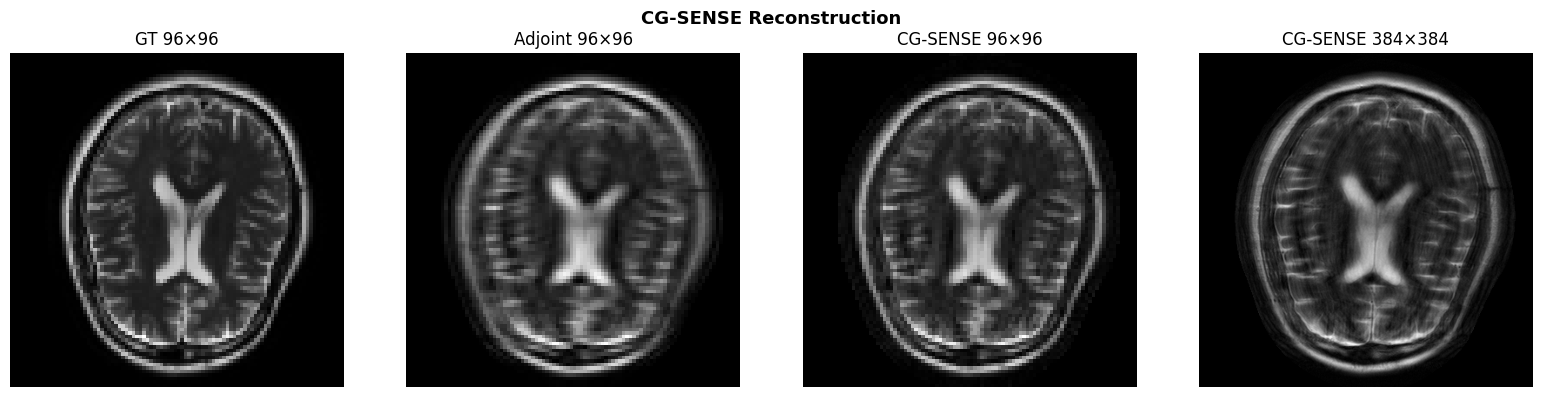

In [96]:
# CG-SENSE baseline images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(magnitude(x_gt_96), cmap='gray'); axes[0].set_title('GT 96×96')
axes[1].imshow(magnitude(zf1),     cmap='gray'); axes[1].set_title('Adjoint 96×96')
axes[2].imshow(magnitude(cg1),     cmap='gray'); axes[2].set_title('CG-SENSE 96×96')
axes[3].imshow(magnitude(cg2),     cmap='gray'); axes[3].set_title('CG-SENSE 384×384')
for ax in axes: ax.axis('off')
plt.suptitle('CG-SENSE Reconstruction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Load Score Networks

In [97]:
def load_model(pkl_path, device):
    print(f'Loading: {pkl_path}')
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    net = data['ema'].to(device).eval()
    n_p = sum(p.numel() for p in net.parameters())
    print(f'  {n_p:,} params | img_resolution={net.img_resolution} | img_channels={net.img_channels}')
    del data
    torch.cuda.empty_cache()
    return net


net_base = load_model(BASE_CKPT, device)
net_sr   = load_model(SR_CKPT,   device)



Loading: /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_base_96/network-snapshot-027597.pkl
  60,483,714 params | img_resolution=96 | img_channels=2
Loading: /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_sr_384/network-snapshot-006203.pkl
  50,512,450 params | img_resolution=384 | img_channels=2


## 7. Stage 1 ALPS — 96×96 Reconstruction

Samples from $p(\mathbf{x}_{96} \mid \mathbf{y}_1)$ where $\mathbf{y}_1$ is the
masked central 96×96 k-space.

In [98]:
opts_base = ALPSOptions(
    num_steps = STEPS_BASE,
    sigma_max = SIGMA_MAX,
    sigma_min = SIGMA_MIN,
    rho       = RHO,
    K         = K,
)

denoiser1 = BaseDenoiser(net_base)

print(f'Stage 1 ALPS: {STEPS_BASE} levels, K={K}')
print(f'Noise schedule: sigma_max={SIGMA_MAX} → sigma_min={SIGMA_MIN}')

# Seed the stochastic sampler so this matches cascaded_ALPS (which reseeds with
# the same SEED before its Stage 1 call).
torch.manual_seed(SEED)
x96, x96_iterates = ALPS(
    A                = A1,
    net              = denoiser1,
    y                = y1,
    opts             = opts_base,
    isALPS           = True,
    storeIntermediate= True,
)


# print(f'\nStage 1 done.  x96: {tuple(x96.shape)}')

Stage 1 ALPS: 10 levels, K=5
Noise schedule: sigma_max=1.0 → sigma_min=0.001


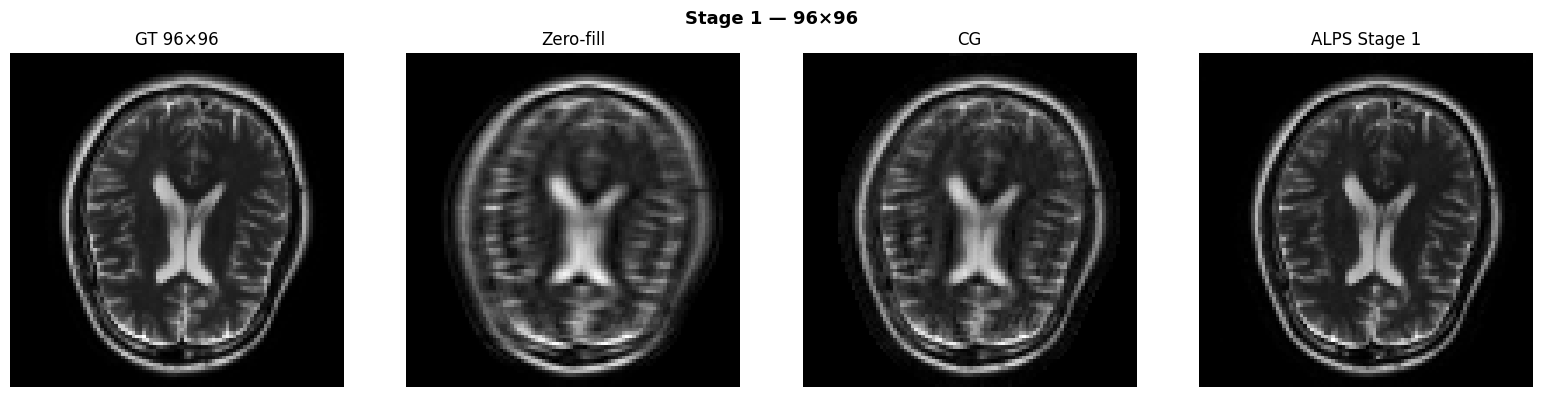

In [99]:
# Visualise Stage 1 result
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(magnitude(x_gt_96), cmap='gray'); axes[0].set_title('GT 96×96')
axes[1].imshow(magnitude(zf1),     cmap='gray'); axes[1].set_title('Zero-fill')
axes[2].imshow(magnitude(cg1),     cmap='gray'); axes[2].set_title('CG')
axes[3].imshow(magnitude(x96),     cmap='gray'); axes[3].set_title('ALPS Stage 1')
for ax in axes: ax.axis('off')
plt.suptitle('Stage 1 — 96×96', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

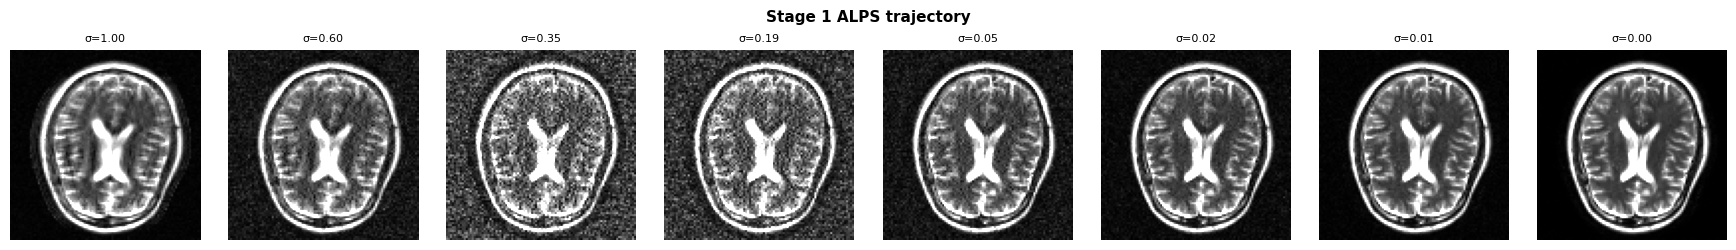

In [100]:
# # ALPS Stage 1 — sampling trajectory
t_steps = giveTsteps(SIGMA_MAX, SIGMA_MIN, RHO, STEPS_BASE, torch.device('cpu'))
n_show  = min(8, STEPS_BASE)
step_idx = np.linspace(0, STEPS_BASE - 1, n_show, dtype=int)

fig, axes = plt.subplots(1, n_show, figsize=(2.2 * n_show, 2.5))
for j, idx in enumerate(step_idx):
    axes[j].imshow(magnitude(x96_iterates[idx]), cmap='gray',vmax=0.5)
    axes[j].set_title(f'σ={t_steps[idx]:.2f}', fontsize=8)
    axes[j].axis('off')
plt.suptitle('Stage 1 ALPS trajectory', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Stage 2 ALPS — 384×384 Reconstruction

Samples from $p(\mathbf{x}_{384} \mid \mathbf{y}_2, \mathbf{x}_{96})$
treating $\mathbf{x}_{96}$ from Stage 1 as fixed conditioning for the
SR score network.

<!-- ### Stage 2 Conditioning Selector

Set `COND_MODE` to switch what feeds into the Stage 2 SR denoiser:

| `COND_MODE` | Source | Purpose |
|---|---|---|
| `'alps'` | Stage 1 ALPS result `x96` | Normal pipeline |
| `'interp'` | GT 384 bilinear-downsampled → 96 | Test SR model with perfect **smooth** LR |
| `'pool'` | GT 384 avg-pooled → 96 | Test SR model with perfect **sharp** LR (same as `x_gt_96`) |

If `'pool'`/`'interp'` recover fine lines but `'alps'` does not → Stage 1 is the bottleneck.  
If none recover fine lines → the SR model itself is the bottleneck (training issue). -->

Stage 2 conditioning: [alps]  —  Stage-1 ALPS
  x96_cond shape : (1, 2, 96, 96)
  x96_cond range : [-0.740, 0.720]


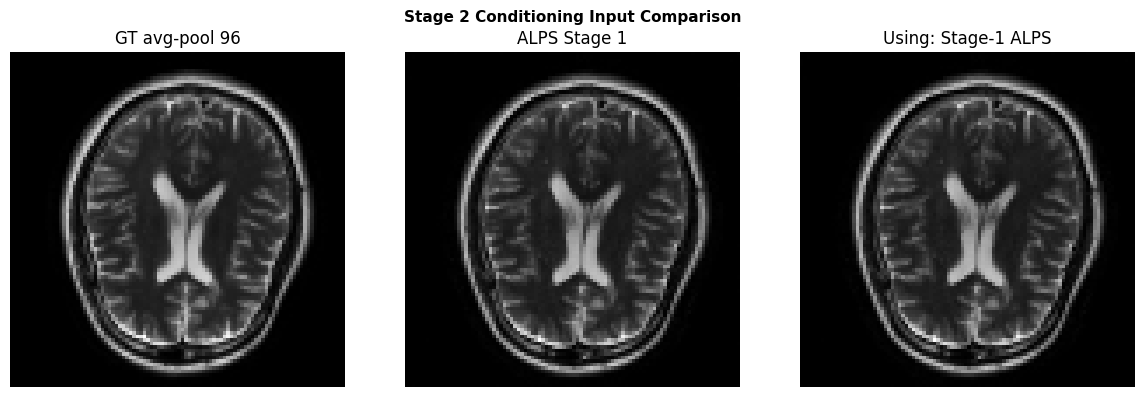

In [ ]:

COND_MODE = 'alps'   

if COND_MODE == 'alps':
    x96_cond = x96
    cond_label = 'Stage-1 ALPS'


elif COND_MODE == 'pool':
   
    x96_cond = x_gt_96.to(device)
    cond_label = 'GT-pool (avg-pool 384→96)'

else:
    raise ValueError(f'Unknown COND_MODE: {COND_MODE!r}. Choose alps / interp / pool.')

print(f'Stage 2 conditioning: [{COND_MODE}]  —  {cond_label}')
print(f'  x96_cond shape : {tuple(x96_cond.shape)}')
print(f'  x96_cond range : [{x96_cond.min():.3f}, {x96_cond.max():.3f}]')

# Quick side-by-side so you can visually inspect what Stage 2 will see
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(magnitude(x_gt_96),  cmap='gray'); axes[0].set_title('GT avg-pool 96')
axes[1].imshow(magnitude(x96),      cmap='gray'); axes[1].set_title('ALPS Stage 1')
axes[2].imshow(magnitude(x96_cond), cmap='gray'); axes[2].set_title(f'Using: {cond_label}')
for ax in axes: ax.axis('off')
plt.suptitle('Stage 2 Conditioning Input Comparison', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [102]:
opts_sr = ALPSOptions(
    num_steps = STEPS_SR,
    sigma_max = SIGMA_MAX,
    sigma_min = SIGMA_MIN,
    rho       = RHO,
    K         = K,
    step_size = STEP_SIZE
)

# Conditioning source is set by COND_MODE cell above (x96_cond).
denoiser2 = SRDenoiser(net_sr, x96_fixed=x96_cond)
# Quick label so figures show which conditioning was used
print(f'  Using conditioning: {cond_label}')


print(f'Stage 2 ALPS: {STEPS_SR} levels, K={K}')
print(f'Conditioning: x96 fixed from Stage 1  {tuple(x96.shape)}')

# Reseed before Stage 2 to match cascaded_ALPS's per-stage seeding.
torch.manual_seed(SEED)
x384, x384_iterates = ALPS(
    A                = A2,
    net              = denoiser2,
    y                = y2,
    opts             = opts_sr,
    isALPS           = True,
    storeIntermediate= True,
)

print(f'\nStage 2 done.  x384: {tuple(x384.shape)}')

  Using conditioning: Stage-1 ALPS
Stage 2 ALPS: 15 levels, K=5
Conditioning: x96 fixed from Stage 1  (1, 2, 96, 96)



Stage 2 done.  x384: (1, 2, 384, 384)


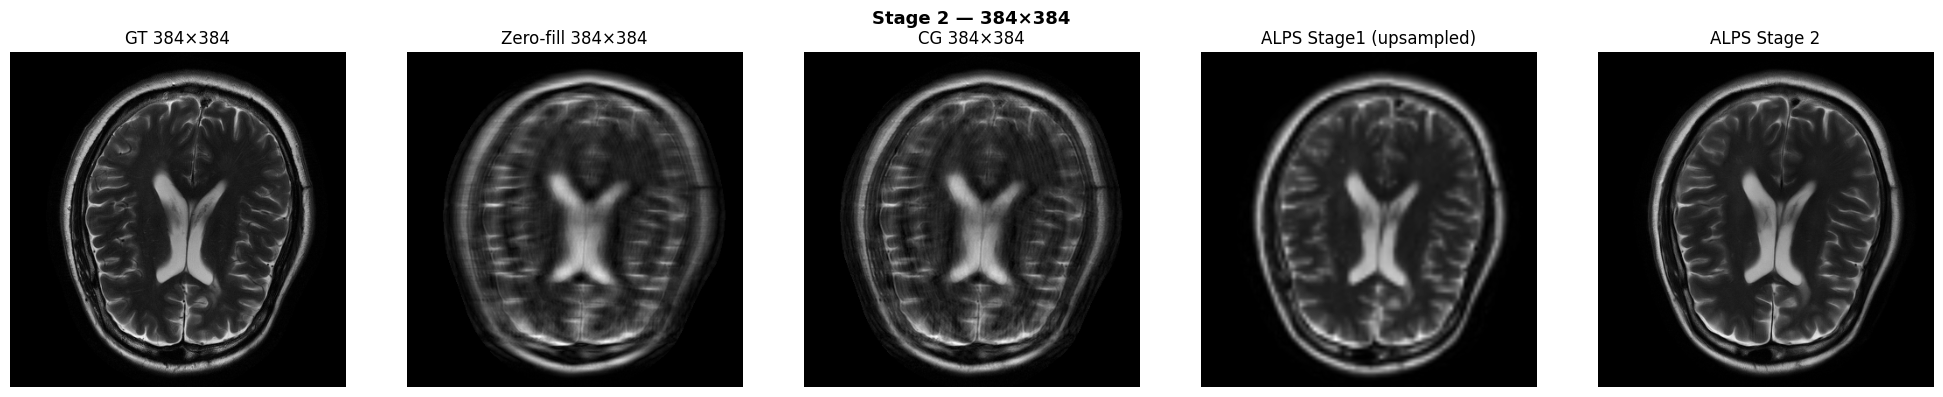

In [103]:
# Visualise Stage 2 result
x96_up = F.interpolate(x96.float(), size=384, mode='bilinear', align_corners=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(magnitude(x_gt),    cmap='gray'); axes[0].set_title('GT 384×384')
axes[1].imshow(magnitude(zf2),     cmap='gray'); axes[1].set_title('Zero-fill 384×384')
axes[2].imshow(magnitude(cg2),     cmap='gray'); axes[2].set_title('CG 384×384')
axes[3].imshow(magnitude(x96_up),  cmap='gray'); axes[3].set_title('ALPS Stage1 (upsampled)')
axes[4].imshow(magnitude(x384),    cmap='gray'); axes[4].set_title('ALPS Stage 2')
for ax in axes: ax.axis('off')
plt.suptitle('Stage 2 — 384×384', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

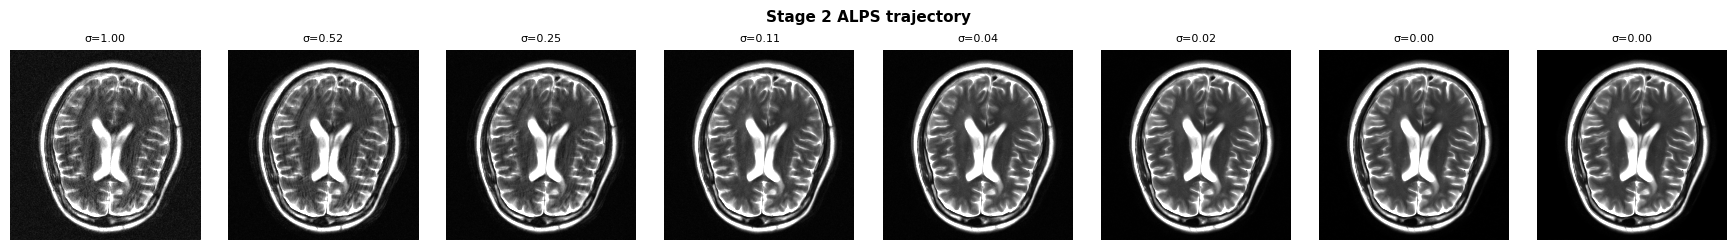

In [104]:
# Stage 2 sampling trajectory
t_steps_sr = giveTsteps(SIGMA_MAX, SIGMA_MIN, RHO, STEPS_SR, torch.device('cpu'))
n_show     = min(8, STEPS_SR)
step_idx   = np.linspace(0, STEPS_SR - 1, n_show, dtype=int)

fig, axes = plt.subplots(1, n_show, figsize=(2.2 * n_show, 2.5))
for j, idx in enumerate(step_idx):
    axes[j].imshow(magnitude(x384_iterates[idx]), cmap='gray',vmax=0.5)
    axes[j].set_title(f'σ={t_steps_sr[idx]:.2f}', fontsize=8)
    axes[j].axis('off')
plt.suptitle('Stage 2 ALPS trajectory', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

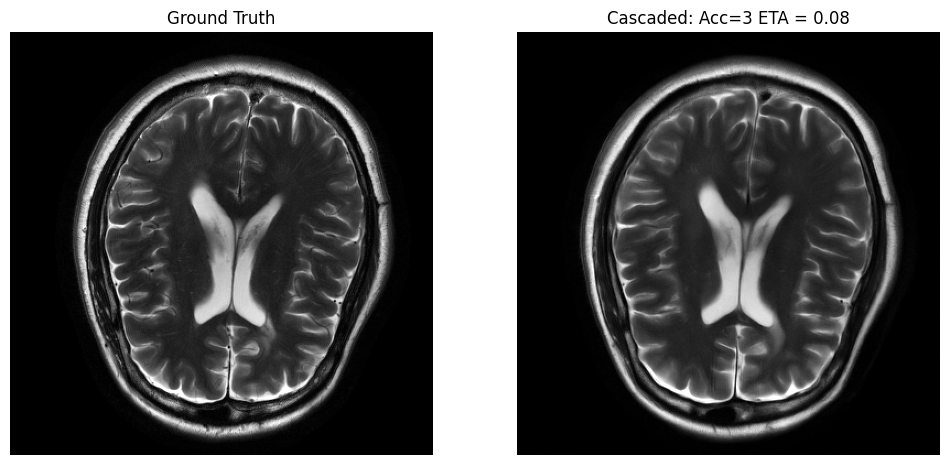

Saved summary figure.


In [105]:
plt.subplots(1, 2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(magnitude(x_gt), cmap='gray',vmax=0.8)
plt.title('Ground Truth', fontsize=12)
plt.axis('off')

plt.subplot(1,2, 2)
plt.imshow(magnitude(x384), cmap='gray',vmax=0.8)
plt.title('Cascaded: Acc='+str(ACCELERATION)+ ' ETA = '+str(ETA), fontsize=12)
plt.axis('off')

plt.savefig(os.path.join(PROJECT_ROOT, f'outputs/alps_summary_Acc={ACCELERATION}_ETA={ETA}.png'))
plt.show()
print('Saved summary figure.')




## 9. Quantitative Metrics

In [208]:
def ssim(x: torch.Tensor, y: torch.Tensor, data_range: float = 2.0) -> float:
    """
    Structural similarity on magnitude images.
    Simplified single-scale implementation (no windowing).
    """
    mx = magnitude(x)
    my = magnitude(y)
    mx = torch.tensor(mx)
    my = torch.tensor(my)
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2
    mu_x, mu_y   = mx.mean(), my.mean()
    sig_x, sig_y = mx.var(), my.var()
    sig_xy = ((mx - mu_x) * (my - mu_y)).mean()
    num    = (2 * mu_x * mu_y + C1) * (2 * sig_xy + C2)
    denom  = (mu_x**2 + mu_y**2 + C1) * (sig_x + sig_y + C2)
    return (num / denom).item()

def psnr(x: torch.Tensor, y: torch.Tensor) -> float:
    """PSNR on magnitude images."""
    mx, my = torch.tensor(magnitude(x)), torch.tensor(magnitude(y))
    mse    = ((mx - my) ** 2).mean().item()
    return 10 * math.log10(1.0 / (mse + 1e-12))

print('Stage 1 (96×96)')
print(f'  Zero-fill  PSNR={psnr(x_gt_96, zf1):.2f} dB   SSIM={ssim(x_gt_96, zf1):.4f}')
print(f'  CG         PSNR={psnr(x_gt_96, cg1):.2f} dB   SSIM={ssim(x_gt_96, cg1):.4f}')
print(f'  ALPS       PSNR={psnr(x_gt_96, x96):.2f} dB   SSIM={ssim(x_gt_96, x96):.4f}')

print('\nStage 2 (384×384)')
print(f'  Zero-fill  PSNR={psnr(x_gt, zf2):.2f} dB   SSIM={ssim(x_gt, zf2):.4f}')
print(f'  CG         PSNR={psnr(x_gt, cg2):.2f} dB   SSIM={ssim(x_gt, cg2):.4f}')
print(f'  ALPS S1↑   PSNR={psnr(x_gt, x96_up):.2f} dB   SSIM={ssim(x_gt, x96_up):.4f}')
print(f'  ALPS S2    PSNR={psnr(x_gt, x384):.2f} dB   SSIM={ssim(x_gt, x384):.4f}')

Stage 1 (96×96)
  Zero-fill  PSNR=23.05 dB   SSIM=0.9343
  CG         PSNR=23.72 dB   SSIM=0.9436
  ALPS       PSNR=16.25 dB   SSIM=0.6436

Stage 2 (384×384)
  Zero-fill  PSNR=22.63 dB   SSIM=0.9116
  CG         PSNR=29.21 dB   SSIM=0.9791
  ALPS S1↑   PSNR=17.40 dB   SSIM=0.6931
  ALPS S2    PSNR=19.27 dB   SSIM=0.7921


## 10. Full Cascade Summary Figure

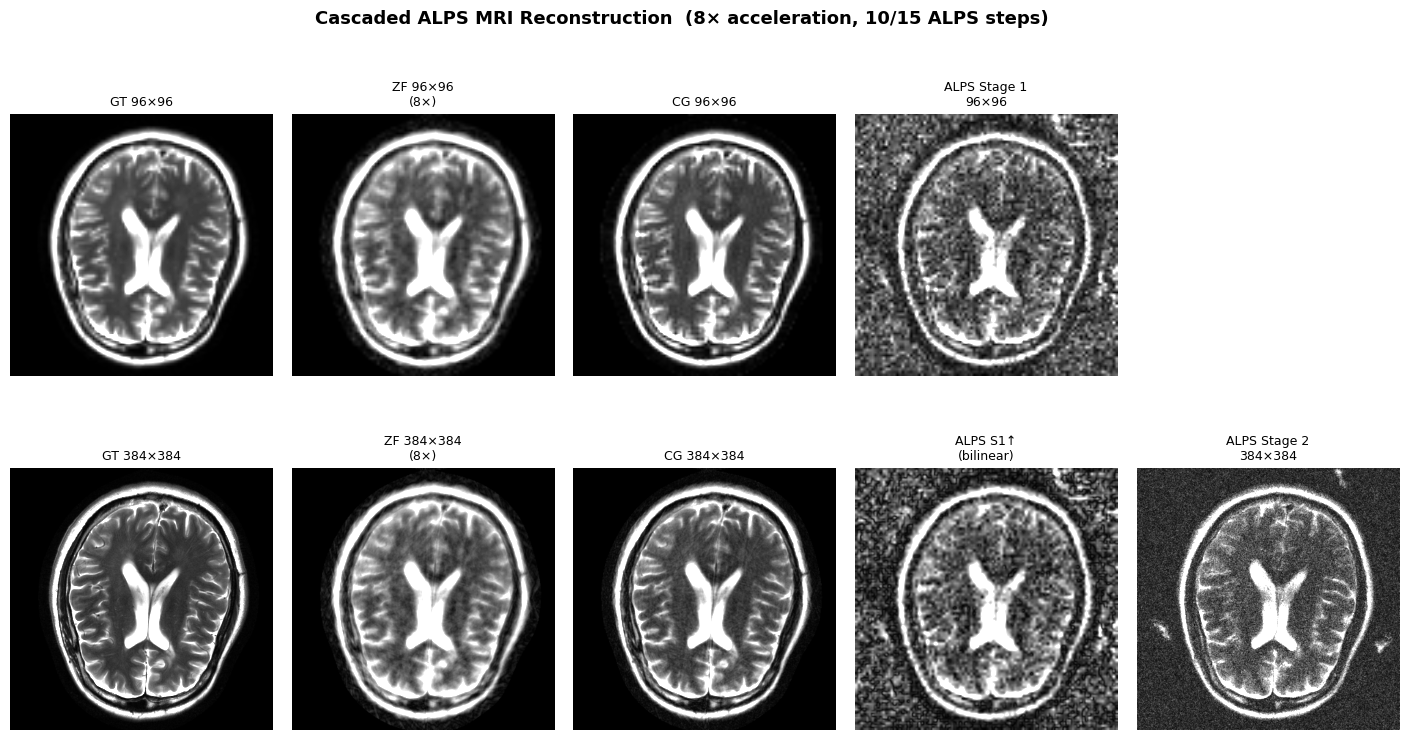

Saved summary figure.


In [209]:
fig = plt.figure(figsize=(18, 8))
gs  = gridspec.GridSpec(2, 5, hspace=0.35, wspace=0.05)

# Row 0 — 96×96 panels (shown as upsampled 384 for visual parity)
def show(ax, img, title):
    ax.imshow(img, cmap='gray', interpolation='bilinear',vmax=0.5)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

show(fig.add_subplot(gs[0,0]), magnitude(x_gt_96),  'GT 96×96')
show(fig.add_subplot(gs[0,1]), magnitude(zf1),      f'ZF 96×96\n({ACCELERATION}×)')
show(fig.add_subplot(gs[0,2]), magnitude(cg1),      'CG 96×96')
show(fig.add_subplot(gs[0,3]), magnitude(x96),      'ALPS Stage 1\n96×96')
ax_empty = fig.add_subplot(gs[0,4]); ax_empty.axis('off')

# Row 1 — 384×384 panels
show(fig.add_subplot(gs[1,0]), magnitude(x_gt),     'GT 384×384')
show(fig.add_subplot(gs[1,1]), magnitude(zf2),      f'ZF 384×384\n({ACCELERATION}×)')
show(fig.add_subplot(gs[1,2]), magnitude(cg2),      'CG 384×384')
show(fig.add_subplot(gs[1,3]), magnitude(x96_up),   'ALPS S1↑\n(bilinear)')
show(fig.add_subplot(gs[1,4]), magnitude(x384),     'ALPS Stage 2\n384×384')

fig.suptitle(
    f'Cascaded ALPS MRI Reconstruction  ({ACCELERATION}× acceleration, '
    f'{STEPS_BASE}/{STEPS_SR} ALPS steps)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(os.path.join(PROJECT_ROOT, 'outputs/alps_cascade_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved summary figure.')

## 11. Save Results

In [210]:
out_dir = os.path.join(PROJECT_ROOT, 'outputs/alps_cascade')
os.makedirs(out_dir, exist_ok=True)

torch.save(x96.cpu(),  os.path.join(out_dir, f'slice{SLICE_IDX:03d}_x96_2ch.pt'))
torch.save(x384.cpu(), os.path.join(out_dir, f'slice{SLICE_IDX:03d}_x384_2ch.pt'))
torch.save(cg1.cpu(),  os.path.join(out_dir, f'slice{SLICE_IDX:03d}_cg96_2ch.pt'))
torch.save(cg2.cpu(),  os.path.join(out_dir, f'slice{SLICE_IDX:03d}_cg384_2ch.pt'))

print(f'Saved to: {out_dir}')

Saved to: /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/outputs/alps_cascade


## 12. (Optional) Run Full Cascade via `cascaded_ALPS`

The `cascaded_ALPS` convenience function wraps Stages 1 and 2 together.
Useful when you don't need intermediate results.

In [211]:
# opts_base = ALPSOptions(
#     num_steps = STEPS_BASE,
#     sigma_max = SIGMA_MAX,
#     sigma_min = SIGMA_MIN,
#     rho       = RHO,
#     K         = K,
# )

# opts_sr = ALPSOptions(
#     num_steps = STEPS_SR,
#     sigma_max = SIGMA_MAX,
#     sigma_min = SIGMA_MIN,
#     rho       = RHO,
#     K         = K,
# )

# result = cascaded_ALPS(
#     multicoil_kspace_384 = kspace_mc,
#     csm_384              = csm,
#     net_base             = net_base,
#     net_sr               = net_sr,
#     opts_base            = opts_base,
#     opts_sr              = opts_sr,
#     acceleration         = ACCELERATION,
#     acs_fraction         = ACS_FRACTION,
#     eta                  = ETA,
#     seed                 = SEED,
#     cg_iters             = CG_ITERS,
#     device               = device,
#     verbose              = True,
# )
# x96_v2  = result['x96']
# x384_v2 = result['x384']